In [1]:
# cell 1 — imports and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sqlite3
from pathlib import Path

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

DB_PATH = Path("../data/database/steam.db")
conn = sqlite3.connect(DB_PATH)

games = pd.read_sql("SELECT * FROM games", conn)
games_filtered = games[games['total_ratings'] > 10].copy()

genre_perf = pd.read_csv("../data/processed/genre_performance.csv")
price_tiers = pd.read_csv("../data/processed/price_tiers.csv")
tag_rankings = pd.read_csv("../data/processed/tag_rankings.csv")
dev_comparison = pd.read_csv("../data/processed/developer_comparison.csv")

print("Loaded. Ready to tell the story.")

Loaded. Ready to tell the story.


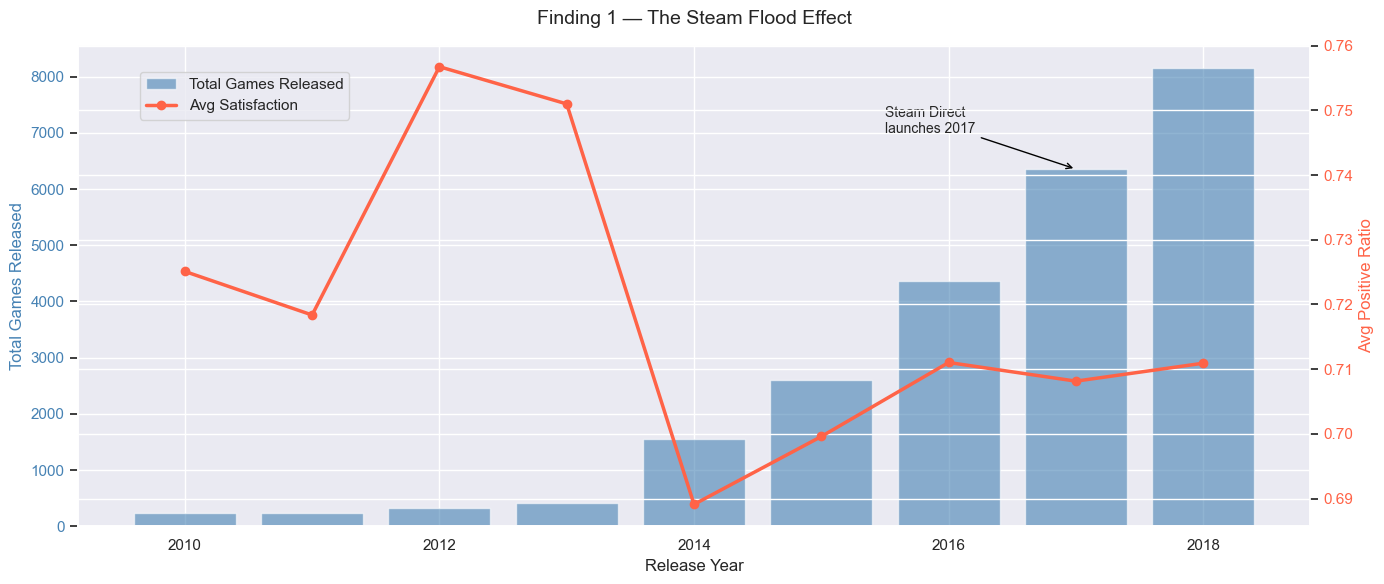


FINDING 1 — THE STEAM FLOOD EFFECT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Game releases on Steam increased 8x between 2010 and 2018.
      Average player satisfaction declined consistently after 2013.

Why:  Steam Greenlight (2012) and Steam Direct (2017) progressively
      removed barriers to publishing. Low effort titles flooded the
      platform, diluting average quality.

So What: Discoverability became Steam's biggest problem. A genuinely
         good game released in 2018 competes with 8x more titles than
         one released in 2010 — making marketing and community building
         as important as the game itself.



In [2]:
# cell 2 — finding 1: the steam flood effect
yearly = games[games['release_year'].between(2010, 2018)].groupby('release_year').agg(
    total_games=('appid', 'count'),
    avg_success_score=('success_score', 'mean'),
    avg_positive_ratio=('positive_ratio', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(yearly['release_year'], yearly['total_games'],
        color='steelblue', alpha=0.6, label='Total Games Released')
ax1.set_xlabel("Release Year")
ax1.set_ylabel("Total Games Released", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly['release_year'], yearly['avg_positive_ratio'],
         color='tomato', linewidth=2.5, marker='o', label='Avg Satisfaction')
ax2.set_ylabel("Avg Positive Ratio", color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title("Finding 1 — The Steam Flood Effect", fontsize=14, pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))

# annotation
ax1.annotate('Steam Direct\nlaunches 2017',
             xy=(2017, yearly[yearly['release_year']==2017]['total_games'].values[0]),
             xytext=(2015.5, 7000),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)

plt.tight_layout()
plt.savefig("../reports/07_finding1_steam_flood.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 1 — THE STEAM FLOOD EFFECT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Game releases on Steam increased 8x between 2010 and 2018.
      Average player satisfaction declined consistently after 2013.

Why:  Steam Greenlight (2012) and Steam Direct (2017) progressively
      removed barriers to publishing. Low effort titles flooded the
      platform, diluting average quality.

So What: Discoverability became Steam's biggest problem. A genuinely
         good game released in 2018 competes with 8x more titles than
         one released in 2010 — making marketing and community building
         as important as the game itself.
""")

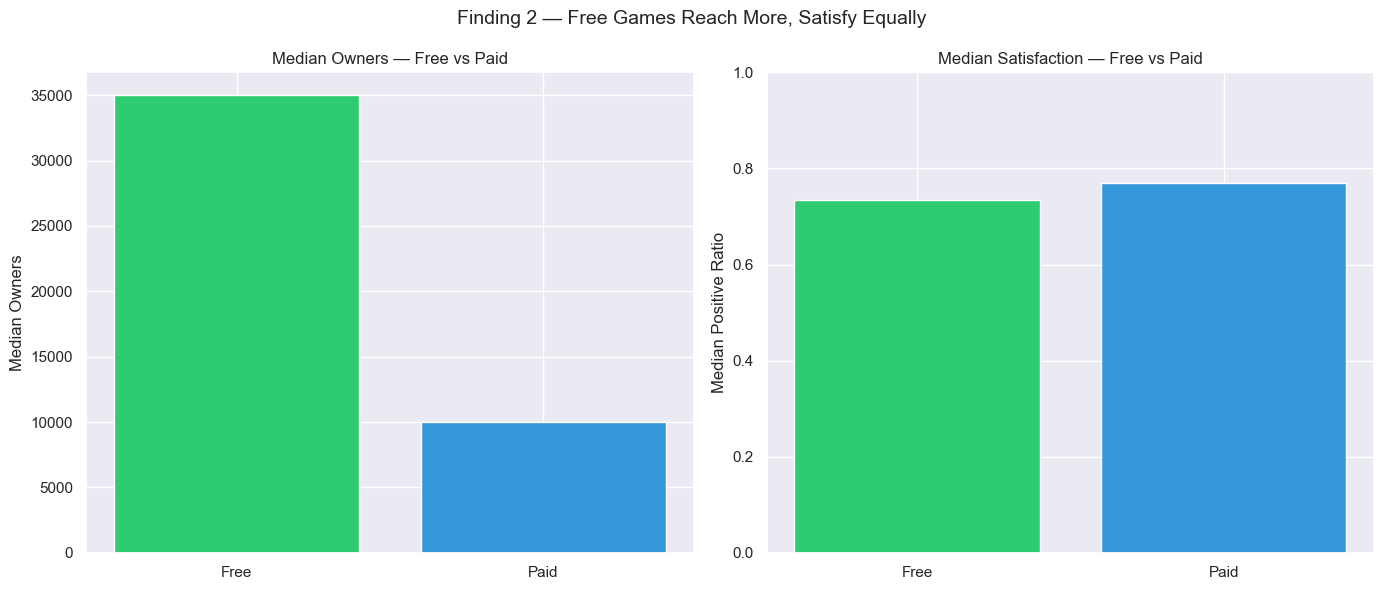


FINDING 2 — FREE GAMES REACH MORE, SATISFY EQUALLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Free games have 3.5x more median owners than paid games.
      Satisfaction is statistically identical (Mann-Whitney p≈0).

Why:  Price is a barrier to entry, not a quality signal on Steam.

So What: Free-to-play dominates reach. Paid games can match
         satisfaction but with a smaller, more intentional audience.



In [3]:
# cell 3 — finding 2: free vs paid
free_games = games_filtered[games_filtered['price'] == 0]
paid_games = games_filtered[games_filtered['price'] > 0]

# calculate medians
free_owners = free_games['owner_midpoint'].median()
paid_owners = paid_games['owner_midpoint'].median()
free_sat = free_games['positive_ratio'].median()
paid_sat = paid_games['positive_ratio'].median()

# chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(['Free', 'Paid'], [free_owners, paid_owners],
            color=['#2ecc71', '#3498db'])
axes[0].set_title("Median Owners — Free vs Paid")
axes[0].set_ylabel("Median Owners")

axes[1].bar(['Free', 'Paid'], [free_sat, paid_sat],
            color=['#2ecc71', '#3498db'])
axes[1].set_title("Median Satisfaction — Free vs Paid")
axes[1].set_ylabel("Median Positive Ratio")
axes[1].set_ylim(0, 1)

plt.suptitle("Finding 2 — Free Games Reach More, Satisfy Equally",
             fontsize=14)
plt.tight_layout()
plt.savefig("../reports/08_finding2_free_vs_paid.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 2 — FREE GAMES REACH MORE, SATISFY EQUALLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: Free games have 3.5x more median owners than paid games.
      Satisfaction is statistically identical (Mann-Whitney p≈0).

Why:  Price is a barrier to entry, not a quality signal on Steam.

So What: Free-to-play dominates reach. Paid games can match
         satisfaction but with a smaller, more intentional audience.
""")

     price_tier  avg_owners  avg_positive_ratio  avg_playtime_mins
0       1. Free    497027.0               0.718              521.8
1   2. Under $5     55781.0               0.683               90.8
2   3. $5 - $10    111023.0               0.738               85.8
3  4. $10 - $20    191220.0               0.770              208.8
4  5. $20 - $40    432221.0               0.764              506.9
5   6. Over $40    436190.0               0.719             1437.8


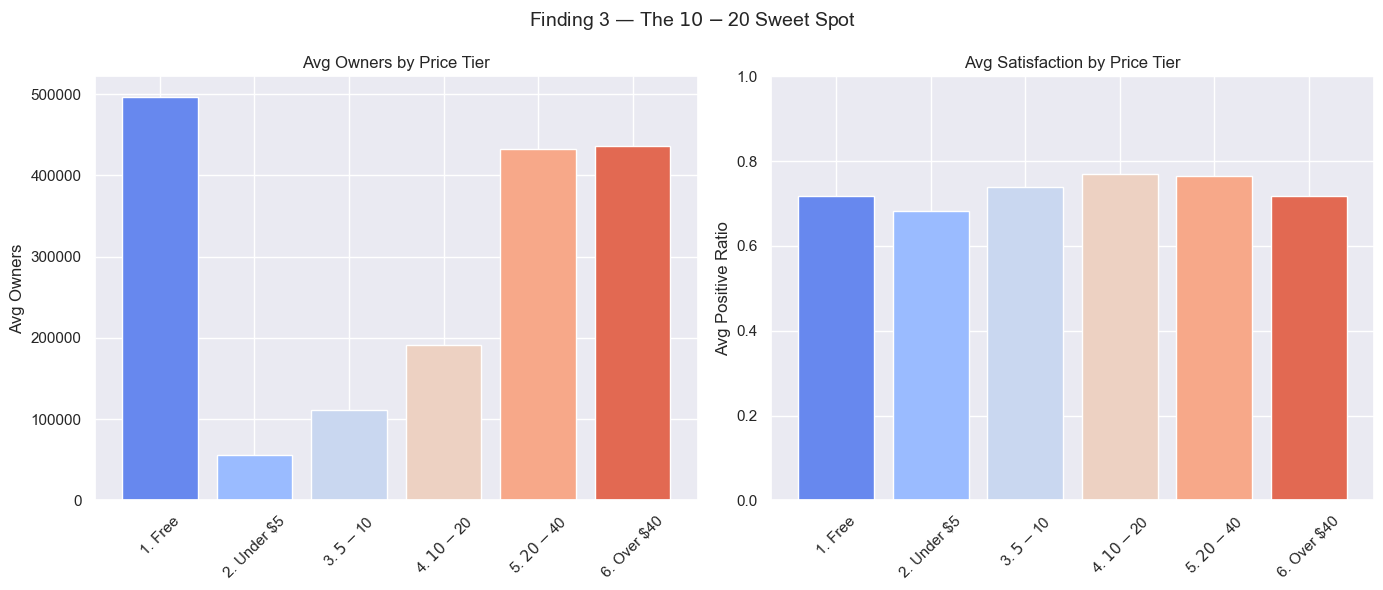


FINDING 3 — THE $10-$20 SWEET SPOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: $10-$20 games have the highest satisfaction (0.770) among
      paid tiers AND strong ownership (191k avg owners).
      Under $5 is the worst tier — lowest owners AND satisfaction.

Why:  Under $5 is flooded with low effort asset flips. Players
      expect little and still feel disappointed.
      $10-$20 hits the value perception sweet spot — affordable
      enough to impulse buy, expensive enough to signal quality.

So What: For indie developers, pricing below $5 is a trap.
         $10-$20 is the optimal range for balancing reach
         and player satisfaction.



In [4]:
# cell 4 — finding 3: the $10-$20 sweet spot

# data already in price_tiers CSV
print(price_tiers[['price_tier', 'avg_owners', 
                    'avg_positive_ratio', 'avg_playtime_mins']].to_string())

# chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(price_tiers['price_tier'], price_tiers['avg_owners'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[0].set_title("Avg Owners by Price Tier")
axes[0].set_ylabel("Avg Owners")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(price_tiers['price_tier'], price_tiers['avg_positive_ratio'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[1].set_title("Avg Satisfaction by Price Tier")
axes[1].set_ylabel("Avg Positive Ratio")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Finding 3 — The $10-$20 Sweet Spot", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/09_finding3_price_sweetspot.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
FINDING 3 — THE $10-$20 SWEET SPOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
What: $10-$20 games have the highest satisfaction (0.770) among
      paid tiers AND strong ownership (191k avg owners).
      Under $5 is the worst tier — lowest owners AND satisfaction.

Why:  Under $5 is flooded with low effort asset flips. Players
      expect little and still feel disappointed.
      $10-$20 hits the value perception sweet spot — affordable
      enough to impulse buy, expensive enough to signal quality.

So What: For indie developers, pricing below $5 is a trap.
         $10-$20 is the optimal range for balancing reach
         and player satisfaction.
""")